# Compute earth-matter induced oscillations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.nsi import earth_matter as em 
from snudd.nsi import oscillation as osc 
from snudd.models import  SM, GeneralNSI
import snudd.nsi.nsi_probabilities as probs
from snudd.nsi.oscillation import OscillationParameters
from snudd.geometry import SolarAngles

## Generate histogram of incident (nadir) angles at Gran Sasso

In [3]:
# Define data taking period 
t0 = 91     # Starting at the perihelion (January 3rd) 
T  = 182*2  # Length of data taking period in days 

# Get angular histogram for Gran Sasso
GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

# Generate nadir angle histogram
cnadirs, weights = GranSasso.cnadir_hist(bins=50)
# print(cnadirs, weights)

In [4]:
# OSC PARAMS
delta_m12 = 7.49e-5 * (1e-9) ** 2  # GeV^2
delta_m31 = 2.513e-3 *( 1e-9) ** 2
theta_12  = 33.68 * np.pi / 180
theta_13  = 8.56 * np.pi / 180  # NORMAL ORDERING
theta_23  = 43.3 * np.pi / 180
delta_cp  = 180  * np.pi / 180  # CP angle


osc_params_test = OscillationParameters(delta_m12,
                                        delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp)


osc_params_best = osc.osc_params_best

## Generate daytime density matrix

In [5]:
# Neutrino energy range in GeV
Enuspace_gev = np.geomspace(1e-3, 2e-2, 1000)
Enuspace     = Enuspace_gev * 1e3     # Mev

# SM neutrino interactions
sm_model = SM()
# sm_model  = GeneralNSI(np.array([[1, 0, 0],
#                         [0, 0, 0],
#                         [0, 0, 0]]),
#                         0, 0)

PREMprob   = em.EarthProbEvolve(osc_params=osc_params_best, model=sm_model, earthmodel=em.PREMmodel, Nst=50, Nav=50 )
density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace_gev, '8B')

The neutrinos arriving at the earth are an incoherent sum of mass eigenstates (they free-stream from the Sun to Earth and decohere). This means that all the phase correlations average out. When we propagate a mass eigenstate through the earth, we don't observe oscillations at low energies. This is different for a coherent flavour eigentstate.

In [26]:
# density_test_mass = np.zeros(shape=(500, 3, 3))
# density_test_mass[:, 0, 0] = np.ones(500)
# Upmns = osc.UPMNS(osc_params_test)

# density_test_mass[:]  = np.matmul(np.matmul(Upmns, density_test_mass[:]), Upmns.conj().T)

# density_test = density_test_mass
# # print(density_test)

## Evolve density matrix through earth

### Generate earth-matter oscillations for one incident angle

In [8]:
# Test one angle (range [0, pi/2] corresponds to passage through matter)
cnadir0 = np.cos(0)

density_curr   = density_sm
rho_earthcnadir1 = PREMprob.evolve_rhosolar(density_curr, Enuspace_gev, cnadir=cnadir0, fast=False)

In [9]:
%%timeit
rho_earthcnadir1 = PREMprob.evolve_rhosolar(density_curr, Enuspace_gev, cnadir=cnadir0)

# With JAX:   39.2 ms ± 4.26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
# Without JAX: 934 ms ± 6.39 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

929 ms ± 3.48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_58535/879358742.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(ymin=-0.1, ymax=1.1)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm MeV}\\right]$')

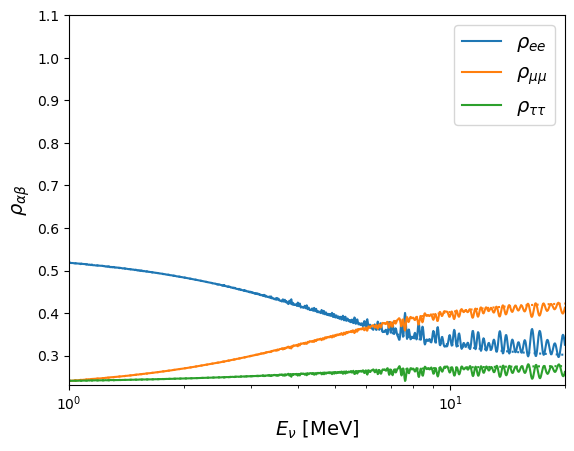

In [9]:


# Plot daytime-only solar neutrino probabilities
plt.loglog(Enuspace,abs(density_curr[:, 0,0]), ls=':', color="tab:blue")
plt.loglog(Enuspace,abs(density_curr[:, 1,1]), ls=':', color="tab:orange")
plt.loglog(Enuspace,abs(density_curr[:, 2,2]), ls=':', color="tab:green")


# Plot matter-evolved probabilities for one angle
plt.loglog(Enuspace,abs(rho_earthcnadir1[:, 0,0]), ls='-', label=r'$\rho_{ee}$',       color="tab:blue" )
plt.loglog(Enuspace,abs(rho_earthcnadir1[:, 1,1]), ls='-', label=r'$\rho_{\mu\mu}$',   color="tab:orange" )
plt.loglog(Enuspace,abs(rho_earthcnadir1[:, 2,2]), ls='-', label=r'$\rho_{\tau\tau}$', color="tab:green" )


plt.xlim(xmin=1e0, xmax=2.0e1)
plt.ylim(ymin=-0.1, ymax=1.1)
plt.yscale('linear')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=1)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm MeV}\right]$', size=14)

## Compute the full density averaged over incident angles

In [10]:
import tqdm as tqdm
from multiprocess import Pool

In [11]:
def rho_weighted_average(probevolution, rhosm, Enuspace, weights, cnadirs, fast=False):


    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)
    
    for i, w in tqdm.tqdm(enumerate(weights), desc='Nadir angles'):

        # evolve through earth
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, cnadir=cnadirs[i], fast=fast)
        rho_ave  += w * rho_earth

    return rho_ave



# Parallel version of rho_weighted_average using multiprocessing Pool
# WARNING: Use only if no JAX arrays are involved, otherwise they will be copied to each process and cause memory issues.
def rho_weighted_average_parallel(probevolution, rhosm, Enuspace, weights, cnadirs, fast=False, nb_core=8):

    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)

    # Arg list of cross sections
    args = []
    for i , w in enumerate(weights):
        args.append((w, cnadirs[i]))

    def parallel_evolve(index):
        weight, cnadir = args[index]
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, cnadir=cnadir, fast=fast)
        return weight * rho_earth
    
    # Run the parallel evolution
    with Pool(nb_core) as pool:
        for result in tqdm.tqdm(pool.imap_unordered(parallel_evolve, range(len(args))), total=len(args), desc='Nadir angles'):
             rho_ave += result

    return rho_ave

In [15]:
# JAX is already optimized for parallel execution, so we can just use the non-parallel version when JAX is enabled. 
# The parallel version is only for NumPy.
if em.USE_JAX:
    rho_ave = rho_weighted_average(PREMprob, density_sm, Enuspace_gev, weights, cnadirs)
else:
    rho_ave = rho_weighted_average_parallel(PREMprob, density_sm, Enuspace_gev, weights, cnadirs, fast=False, nb_core=8)

Nadir angles: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]


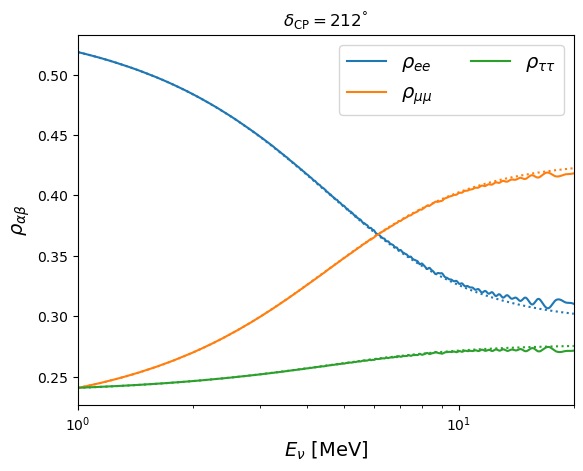

In [16]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]), ls=':', color="tab:blue" )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]), ls=':', color="tab:orange")
plt.loglog(Enuspace,abs(density_sm[:, 2,2]), ls=':', color="tab:green")

plt.loglog(Enuspace,abs(rho_ave[:, 0,0]), label=r'$\rho_{ee}$',        color="tab:blue" )
plt.loglog(Enuspace,abs(rho_ave[:, 1,1]), label=r'$\rho_{\mu\mu}$',    color="tab:orange" )
plt.loglog(Enuspace,abs(rho_ave[:, 2,2]), label=r'$\rho_{\tau\tau}$',  color="tab:green" )



plt.xlim(xmin=1e0, xmax=2.0e1)
plt.yscale('linear')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=212^\degree$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm MeV}\right]$', size=14)

plt.savefig("earth_matter_prob_{}.png".format(int(len(Enuspace))), dpi=300)

To have accurate averaging, we need a sufficient density of point in the energy region ~[5, 20] MeV

## Run with old oscillation parameters

In [17]:
params_old = osc.osc_params_old

rho_sun2  = probs.DensityMatrixCalculator(sm_model, osc_params=params_old).density(Enuspace_gev, '8B')
PREMprob2 = em.EarthProbEvolve(osc_params=params_old, model=sm_model, earthmodel=em.PREMmodel)

In [18]:
# JAX is already optimized for parallel execution, so we can just use the non-parallel version when JAX is enabled. 
# The parallel version is only for NumPy.
if em.USE_JAX:
    rho_ave2 = rho_weighted_average(PREMprob2, rho_sun2, Enuspace_gev, weights, cnadirs)
else:
    rho_ave2 = rho_weighted_average_parallel(PREMprob2, rho_sun2, Enuspace_gev, weights, cnadirs)

Nadir angles: 50it [00:00, 76.70it/s]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

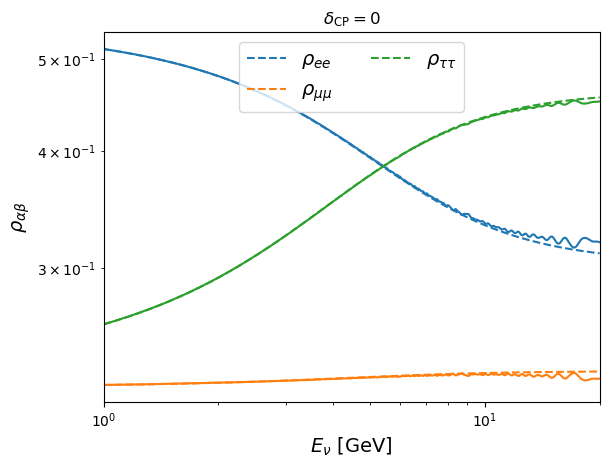

In [19]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$', color="tab:orange", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\tau\tau}$', color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave2[:, 0,0]),  color="tab:blue" )
plt.loglog(Enuspace,abs(rho_ave2[:, 1,1]),  color="tab:orange" )
plt.loglog(Enuspace,abs(rho_ave2[:, 2,2]),  color="tab:green" )


plt.xlim(xmin=1e0, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=0$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)